In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ======================================================================
# Quantitative Portfolio Optimization & Risk Assessment
# ======================================================================
# Author    : Kesidis Angelos
# ETFs      : SCHD, VTI, VOO, VT, VXUS, QQQ
# Big Tech  : AAPL, MSFT, NVDA, AMZN, GOOGL, META, AMD, AVGO, INTC, MU
# Dividends : JNJ, PFE, KO, PG, PEP, VZ, IBM, MCD, ABBV, MDT
# Consumer  : WMT, COST, HD, XOM, CVX, JPM, BAC, CSCO
# Extra     : UAA, KDP, MDLZ, SYY, PLD, O
# Benchmark : S&P 500 (^GSPC)
# Period    : 2015-01-01 to Today
# ======================================================================

# Data Collection

In [3]:
# ======================================================================
# SECTION 1 — Data Collection
# ======================================================================

etf       = ['SCHD', 'VTI', 'VOO', 'VT', 'VXUS', 'QQQ']
big_tech  = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'AMD', 'AVGO', 'INTC', 'MU']
dividends = ['JNJ', 'PFE', 'KO', 'PG', 'PEP', 'VZ', 'IBM', 'MCD', 'ABBV', 'MDT']
consumer  = ['WMT', 'COST', 'HD', 'XOM', 'CVX', 'JPM', 'BAC', 'CSCO']
extra     = ['UAA', 'KDP', 'MDLZ', 'SYY', 'PLD', 'O']
 
stocks  = etf + big_tech + dividends + consumer + extra
tickers = stocks + ["^GSPC"]
 
data = yf.download(tickers, start="2015-01-01")["Close"]
 
print("Shape   :", data.shape)
print("Columns :", list(data.columns))
print("\nFirst rows :")
print(data.head())
print("\nLast rows :")
print(data.tail())
print("\nMissing values per column :")
print(data.isnull().sum())

[*********************100%***********************]  41 of 41 completed


Shape   : (2854, 41)
Columns : ['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO', 'BAC', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'KDP', 'KO', 'MCD', 'MDLZ', 'MDT', 'META', 'MSFT', 'MU', 'NVDA', 'O', 'PEP', 'PFE', 'PG', 'PLD', 'QQQ', 'SCHD', 'SYY', 'UAA', 'VOO', 'VT', 'VTI', 'VXUS', 'VZ', 'WMT', 'XOM', '^GSPC']

First rows :
Ticker           AAPL       ABBV   AMD     AMZN      AVGO        BAC  \
Date                                                                   
2015-01-02  24.214884  41.411911  2.67  15.4260  7.544513  14.123796   
2015-01-05  23.532721  40.632576  2.66  15.1095  7.423910  13.713502   
2015-01-06  23.534931  40.431446  2.63  14.7645  7.255067  13.303200   
2015-01-07  23.864948  42.065556  2.58  14.9210  7.451047  13.366328   
2015-01-08  24.781891  42.505497  2.61  15.0230  7.823408  13.642488   

Ticker            COST       CSCO        CVX      GOOGL  ...        SYY  \
Date                                                     ...              
201

# Normalization & Price Performance

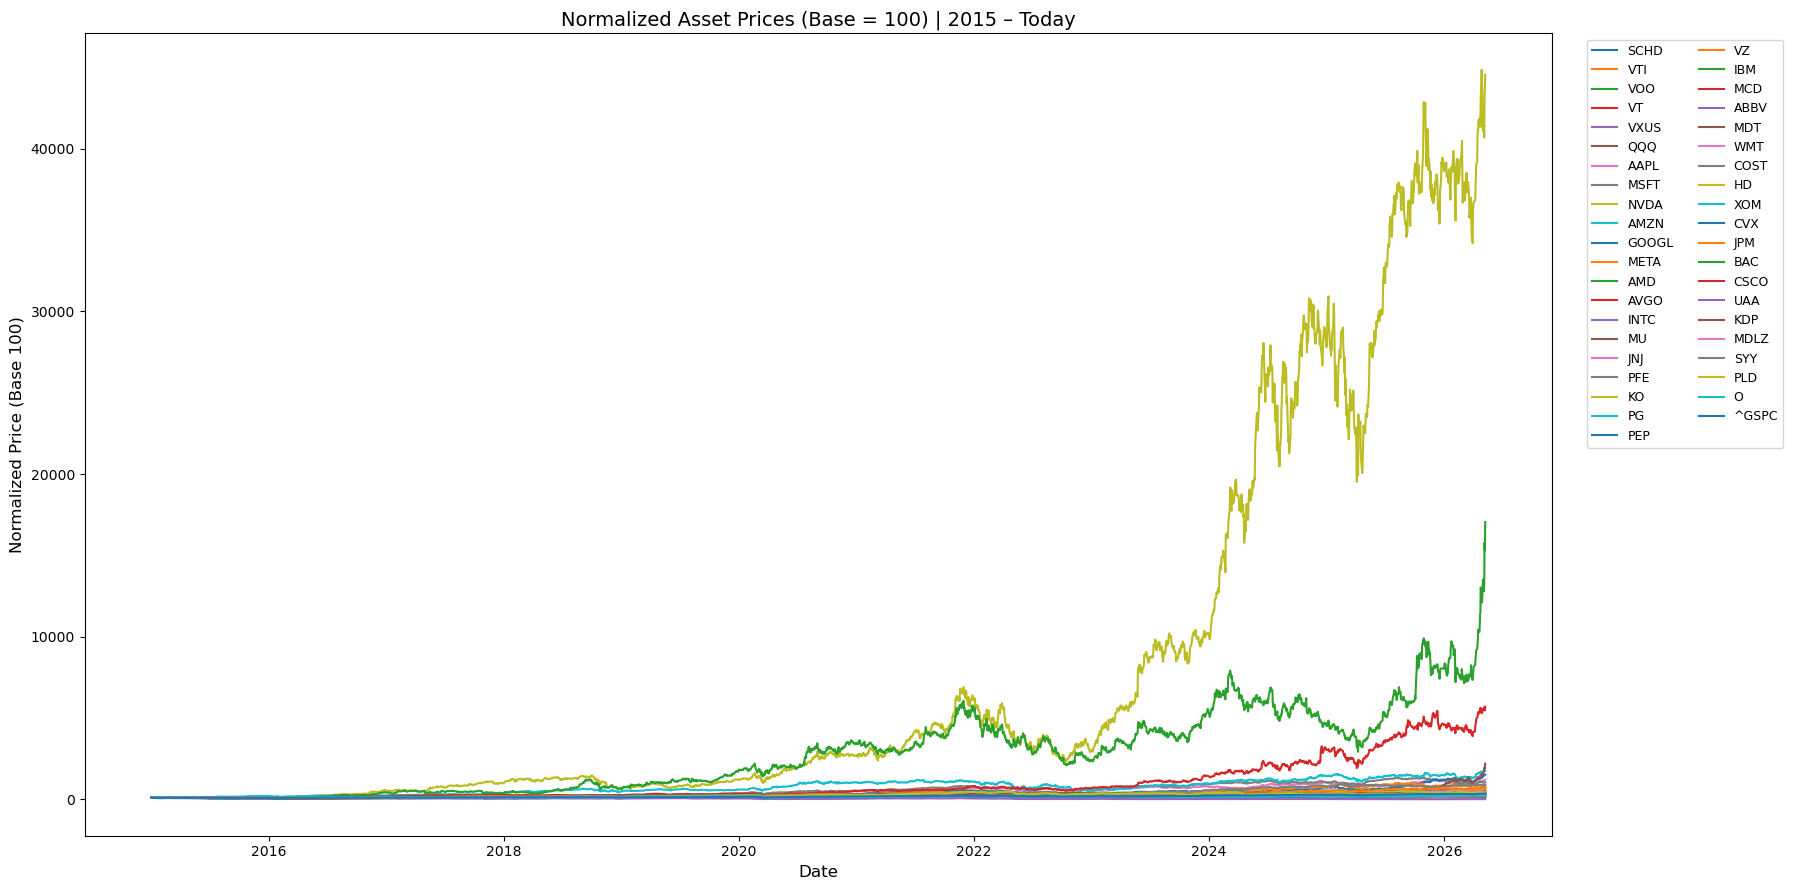

In [4]:
# ======================================================================
# SECTION 2 — Normalization & Price Performance
# ======================================================================

normalization = (data[tickers] / data[tickers].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalization.columns:
    plt.plot(normalization[col], label=col)
 
plt.title("Normalized Asset Prices (Base = 100) | 2015 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=2, fontsize=9)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

# Log Returns

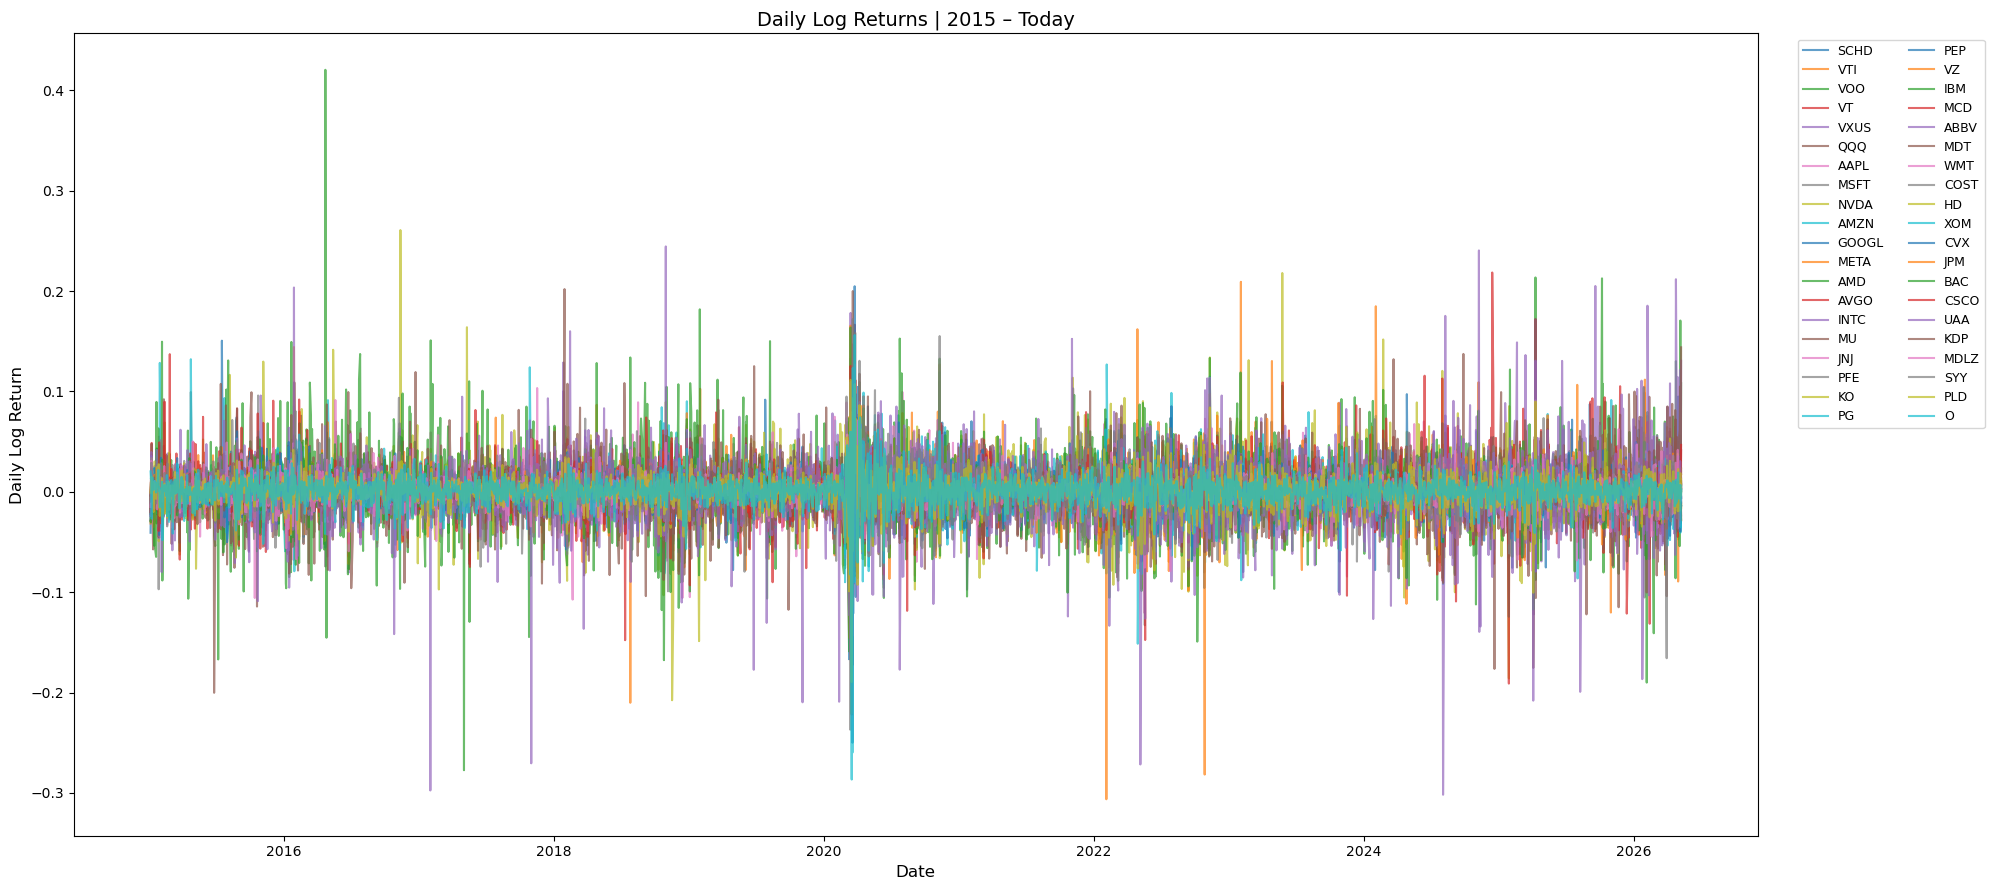

In [5]:
# ======================================================================
# SECTION 3 — Log Returns
# ======================================================================
 
log_return = np.log(data / data.shift(1))
 
plt.figure(figsize=(20, 9))
for col in stocks:
    plt.plot(log_return[col], label=col, alpha=0.7)
 
plt.title("Daily Log Returns | 2015 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=2, fontsize=9)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

# Individual Asset Risk & Return

In [6]:
# ======================================================================
# SECTION 4 — Individual Asset Risk & Return
# ======================================================================
 
annual_return   = log_return[stocks].mean() * 250
annual_variance = log_return[stocks].var()  * 250
annual_std      = log_return[stocks].std()  * (250 ** 0.5)
 
rf = 0.043  # Risk-free rate: US 10-Year Treasury (2025-2026)
sharpe_ratio = (annual_return - rf) / annual_std
 
summary_individual = pd.DataFrame({
    "Annual Return (%)":    (annual_return   * 100).round(2),
    "Annual Variance":       annual_variance.round(6),
    "Volatility / Risk (%)": (annual_std      * 100).round(2),
    "Sharpe Ratio":          sharpe_ratio.round(3)
})
 
print("\n===== Individual Asset Risk & Return Summary =====")
print(summary_individual.to_string())


===== Individual Asset Risk & Return Summary =====
        Annual Return (%)  Annual Variance  Volatility / Risk (%)  Sharpe Ratio
Ticker                                                                         
SCHD                10.86         0.026995                  16.43         0.400
VTI                 12.43         0.032338                  17.98         0.452
VOO                 12.92         0.031435                  17.73         0.486
VT                  10.46         0.029268                  17.11         0.360
VXUS                 7.93         0.029779                  17.26         0.210
QQQ                 17.67         0.047645                  21.83         0.613
AAPL                21.86         0.081773                  28.60         0.614
MSFT                20.55         0.072752                  26.97         0.603
NVDA                53.45         0.228904                  47.84         1.027
AMZN                25.17         0.106396                  32.62   

# Efficient Frontier (Monte Carlo Simulation)

In [7]:
# ======================================================================
# SECTION 5 — Efficient Frontier (Monte Carlo Simulation)
# ======================================================================
 
cov_matrix_annual = log_return[stocks].cov() * 250  # OUTSIDE the loop
num_assets = len(stocks)
 
portfolio_returns      = []
portfolio_volatilities = []
portfolio_weights_list = []
 
for _ in range(10000):
    weights  = np.random.random(num_assets)
    weights /= np.sum(weights)
 
    p_ret = np.sum(weights * log_return[stocks].mean() * 250)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annual, weights)))
 
    portfolio_returns.append(p_ret)
    portfolio_volatilities.append(p_vol)
    portfolio_weights_list.append(weights)
 
portfolio_returns      = np.array(portfolio_returns)
portfolio_volatilities = np.array(portfolio_volatilities)
 
portfolio_sharpes = (portfolio_returns - rf) / portfolio_volatilities
 
portfolios = pd.DataFrame({
    "Return":     portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe":     portfolio_sharpes
})
 
min_var_idx    = portfolios["Volatility"].idxmin()
max_sharpe_idx = portfolios["Sharpe"].idxmax()      # FIX #1: MSP not MRP
 
MVP = portfolios.loc[min_var_idx]
MSP = portfolios.loc[max_sharpe_idx]
 
best_weights_MVP = portfolio_weights_list[min_var_idx]
best_weights_MSP = portfolio_weights_list[max_sharpe_idx]
 
print("\nMax Sharpe Ratio :", round(portfolios["Sharpe"].max(), 3))
print("Min Volatility   :", round(portfolio_volatilities.min() * 100, 2), "%")
 
print("\nMinimum Variance Portfolio (MVP):")
print(f"  Return    : {round(MVP['Return'] * 100, 2)}%")
print(f"  Volatility: {round(MVP['Volatility'] * 100, 2)}%")
print(f"  Sharpe    : {round(MVP['Sharpe'], 3)}")
 
print("\nMaximum Sharpe Portfolio (MSP):")
print(f"  Return    : {round(MSP['Return'] * 100, 2)}%")
print(f"  Volatility: {round(MSP['Volatility'] * 100, 2)}%")
print(f"  Sharpe    : {round(MSP['Sharpe'], 3)}")


Max Sharpe Ratio : 0.735
Min Volatility   : 15.52 %

Minimum Variance Portfolio (MVP):
  Return    : 11.22%
  Volatility: 15.52%
  Sharpe    : 0.446

Maximum Sharpe Portfolio (MSP):
  Return    : 17.59%
  Volatility: 18.07%
  Sharpe    : 0.735


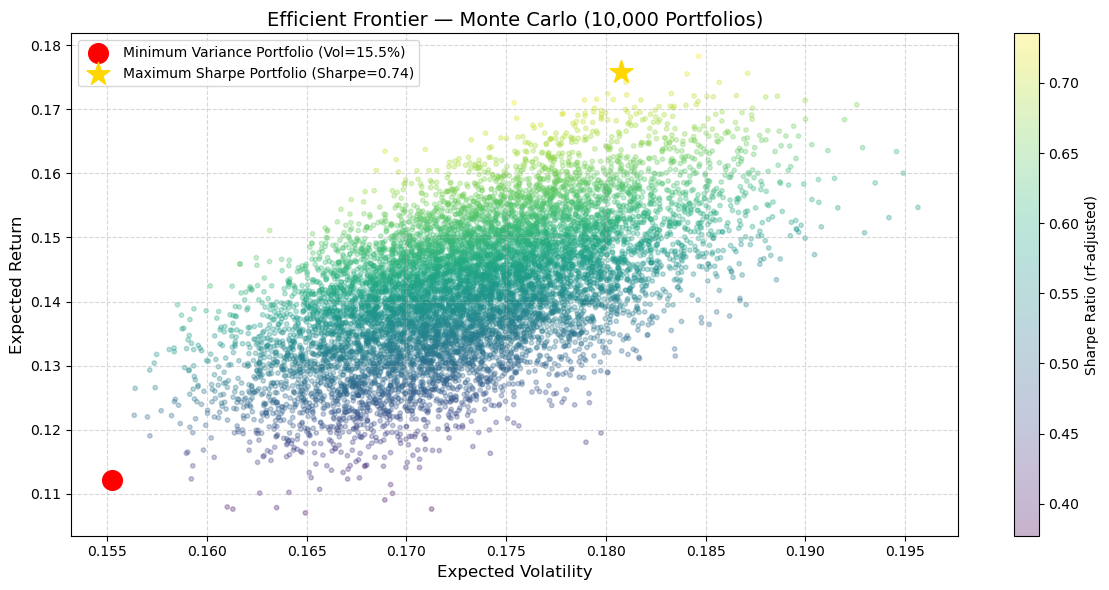

In [8]:
# --- Plot Efficient Frontier ---

plt.figure(figsize=(12, 6))
 
sc = plt.scatter(
    portfolios["Volatility"], portfolios["Return"],
    c=portfolio_sharpes,               # FIX #3: proper Sharpe with rf
    marker='o', s=10, alpha=0.3, cmap='viridis'
)
 
plt.scatter(MVP["Volatility"], MVP["Return"],
            color='red', marker='o', s=200, zorder=5,
            label=f"Minimum Variance Portfolio (Vol={round(MVP['Volatility']*100,1)}%)")
 
plt.scatter(MSP["Volatility"], MSP["Return"],
            color='gold', marker='*', s=300, zorder=5,
            label=f"Maximum Sharpe Portfolio (Sharpe={round(MSP['Sharpe'],2)})")
 
plt.title("Efficient Frontier — Monte Carlo (10,000 Portfolios)", fontsize=14)
plt.xlabel("Expected Volatility", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)
plt.legend()
plt.colorbar(sc, label='Sharpe Ratio (rf-adjusted)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Portfolio Construction & Comparison

In [9]:
# ======================================================================
# SECTION 6 — Portfolio Construction & Comparison
# ======================================================================
 
my_weights = np.array([1 / num_assets] * num_assets)
 
my_ret = np.sum(my_weights * log_return[stocks].mean() * 250)
my_vol = np.sqrt(np.dot(my_weights.T, np.dot(cov_matrix_annual, my_weights)))
 
portfolio_return     = my_ret
portfolio_variance   = np.dot(my_weights.T, np.dot(cov_matrix_annual, my_weights))
portfolio_volatility = portfolio_variance ** 0.5
 
print(f"\n--- My Equal-Weight Portfolio ({num_assets} Assets) ---")
print(f"Return    : {round(my_ret * 100, 2)}%")
print(f"Volatility: {round(my_vol * 100, 2)}%")
print(f"Sharpe    : {round((my_ret - rf) / my_vol, 3)}")
 
print(f"\n--- Optimized Portfolios (From Simulation) ---")
print(f"MVP | Return: {round(MVP['Return']*100,2)}% | Volatility: {round(MVP['Volatility']*100,2)}% | Sharpe: {round(MVP['Sharpe'],3)}")
print(f"MSP | Return: {round(MSP['Return']*100,2)}% | Volatility: {round(MSP['Volatility']*100,2)}% | Sharpe: {round(MSP['Sharpe'],3)}")


--- My Equal-Weight Portfolio (40 Assets) ---
Return    : 14.21%
Volatility: 17.21%
Sharpe    : 0.576

--- Optimized Portfolios (From Simulation) ---
MVP | Return: 11.22% | Volatility: 15.52% | Sharpe: 0.446
MSP | Return: 17.59% | Volatility: 18.07% | Sharpe: 0.735



===== Optimal Weights Assignment =====
    Asset  MVP_Weight  MSP_Weight
0    SCHD        4.92        1.32
18     KO        4.92        1.31
21     VZ        4.76        1.38
19     PG        4.74        3.09
36   MDLZ        4.62        0.31
24   ABBV        4.52        0.48
37    SYY        4.49        1.11
10  GOOGL        4.33        1.39
17    PFE        4.14        0.42
20    PEP        4.13        2.47
32    BAC        4.06        1.00
22    IBM        3.60        0.50
35    KDP        3.39        0.62
27   COST        3.38        5.25
6    AAPL        3.30        0.30
9    AMZN        3.19        3.74
25    MDT        3.16        1.84
34    UAA        2.97        0.22
4    VXUS        2.91        0.10
33   CSCO        2.73        1.76
28     HD        2.69        5.56
16    JNJ        2.68        5.61
38    PLD        2.64        5.36
26    WMT        2.62        3.24
3      VT        1.85        3.75
5     QQQ        1.64        3.92
29    XOM        1.02        5.49
11   MET

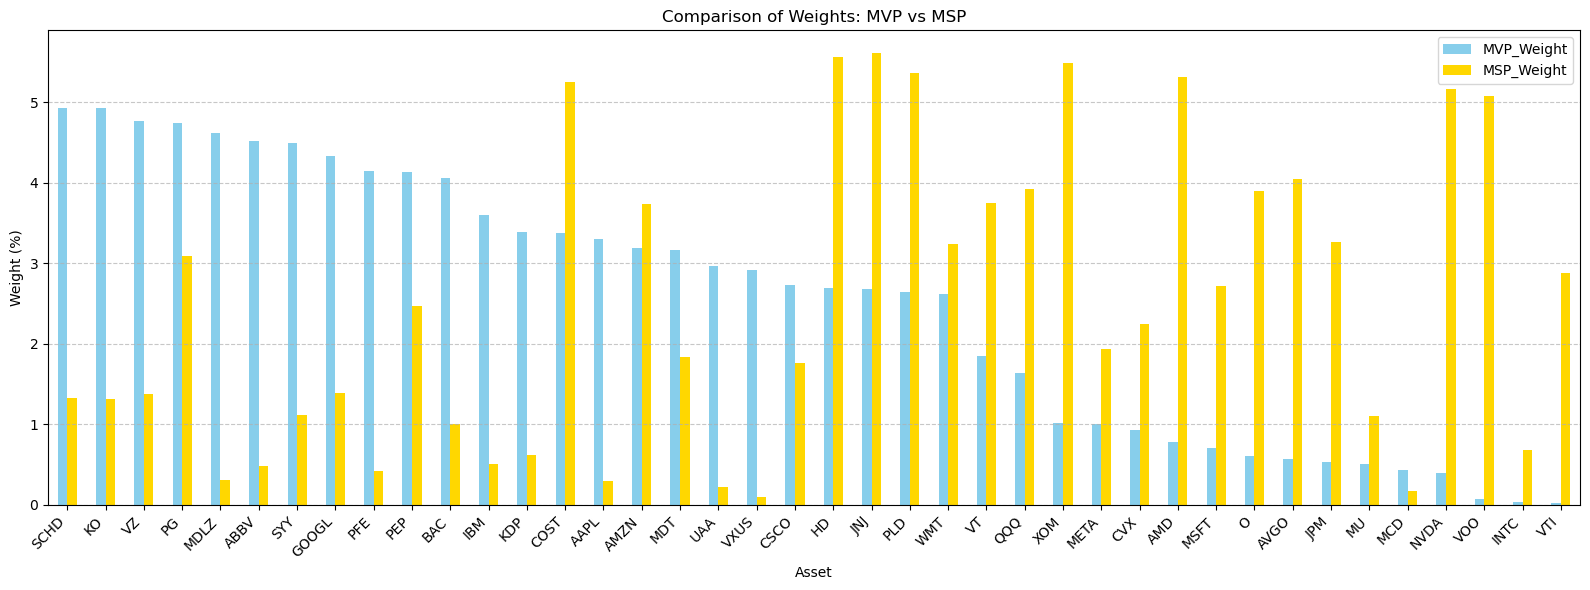

In [10]:
# --- Weights Comparison Table ---

weights_df = pd.DataFrame({
    'Asset':      stocks,
    'MVP_Weight': (best_weights_MVP * 100).round(2),
    'MSP_Weight': (best_weights_MSP * 100).round(2)
})
 
print("\n===== Optimal Weights Assignment =====")
print(weights_df.sort_values(by="MVP_Weight", ascending=False).to_string())
 
weights_df.set_index('Asset').sort_values(by="MVP_Weight", ascending=False).plot(
    kind='bar', figsize=(16, 6), color=['skyblue', 'gold']
)
plt.title("Comparison of Weights: MVP vs MSP")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Covariance & Correlation Analysis

In [11]:
# ======================================================================
# SECTION 7 — Covariance & Correlation Analysis
# ======================================================================

# --- Covariance Matrix (annualized) ---
annual_covariance = log_return[stocks].cov() * 250
 
print("\n===== Annual Covariance Matrix =====")
print(annual_covariance.round(6))
 
# --- Correlation Matrix (NEVER * 250) ---
correlation_matrix = log_return[stocks].corr()
 
print("\n===== Correlation Matrix =====")
print(correlation_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(correlation_matrix.values).round(3))


===== Annual Covariance Matrix =====
Ticker      SCHD       VTI       VOO        VT      VXUS       QQQ      AAPL  \
Ticker                                                                         
SCHD    0.026995  0.025992  0.025719  0.024415  0.022155  0.025734  0.027698   
VTI     0.025992  0.032338  0.031746  0.029984  0.026605  0.036461  0.037602   
VOO     0.025719  0.031746  0.031435  0.029468  0.026075  0.036104  0.037673   
VT      0.024415  0.029984  0.029468  0.029268  0.027938  0.033497  0.034144   
VXUS    0.022155  0.026605  0.026075  0.027938  0.029779  0.029033  0.029080   
QQQ     0.025734  0.036461  0.036104  0.033497  0.029033  0.047645  0.049686   
AAPL    0.027698  0.037602  0.037673  0.034144  0.029080  0.049686  0.081773   
MSFT    0.025822  0.036845  0.037059  0.033469  0.028199  0.049146  0.049795   
NVDA    0.034044  0.055864  0.055092  0.050819  0.043090  0.077620  0.072173   
AMZN    0.022489  0.037199  0.036895  0.033443  0.027874  0.053675  0.051292   
GO

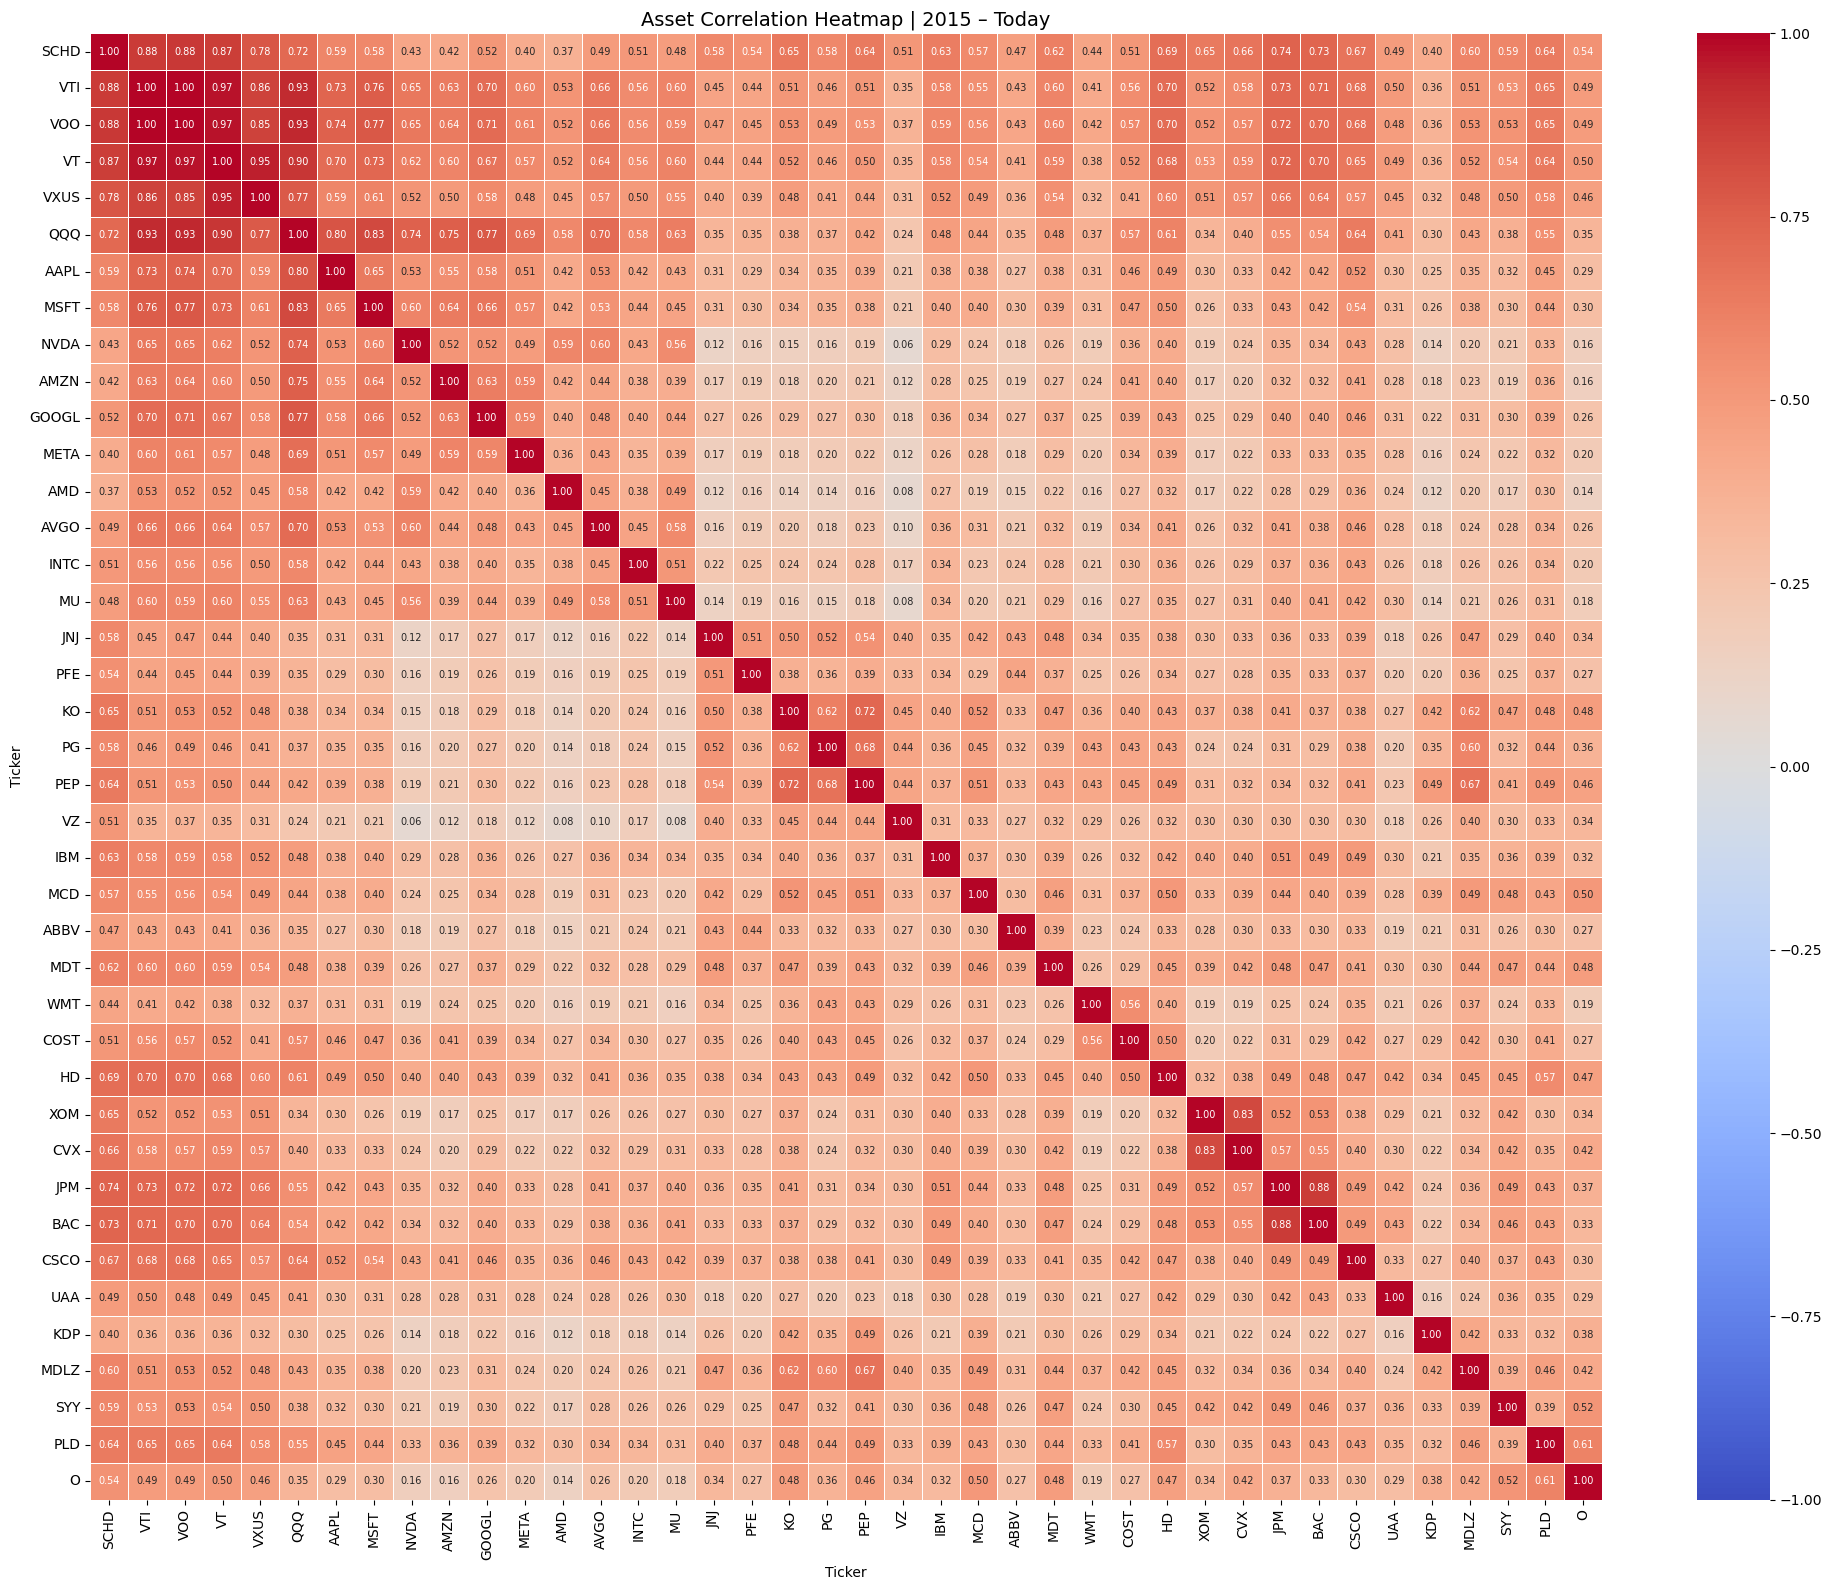

In [12]:
# --- Heatmap ---

plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
plt.title("Asset Correlation Heatmap | 2015 – Today", fontsize=14)  # FIX #4: corrected year
plt.tight_layout()
plt.show()

# Portfolio Variance & Risk Decomposition

In [13]:
# ======================================================================
# SECTION 8 — Portfolio Variance & Risk Decomposition
# ======================================================================

print("\n===== Portfolio Variance & Volatility =====")
print(f"Variance  : {portfolio_variance:.6f}")
print(f"Volatility: {round(portfolio_volatility * 100, 2)}%")

# Worst-case variance: αν όλα assets είχαν ρ = +1 (zero diversification)
# = (Σ wᵢ * σᵢ)² 
weighted_avg_vol = np.sum(my_weights * np.sqrt(annual_variance[stocks].values))
wiv = weighted_avg_vol ** 2  # variance under ρ=1 assumption

diversification_benefit = wiv - portfolio_variance
diversification_ratio   = (diversification_benefit / wiv) * 100

print("\n===== Risk Decomposition (Equal-Weight Portfolio) =====")
print(f"Worst-Case Variance (ρ=1)  : {wiv:.6f}  (if all assets moved perfectly together)")
print(f"Actual Portfolio Variance  : {portfolio_variance:.6f}  (with real correlations)")
print(f"Diversification Benefit    : {diversification_benefit:.6f}  (variance eliminated)")
print(f"Diversification Ratio      : {round(diversification_ratio, 1)}%  (% of risk removed)")


===== Portfolio Variance & Volatility =====
Variance  : 0.029616
Volatility: 17.21%

===== Risk Decomposition (Equal-Weight Portfolio) =====
Worst-Case Variance (ρ=1)  : 0.074606  (if all assets moved perfectly together)
Actual Portfolio Variance  : 0.029616  (with real correlations)
Diversification Benefit    : 0.044990  (variance eliminated)
Diversification Ratio      : 60.3%  (% of risk removed)


# Regression Analysis: Each Stock vs S&P 500

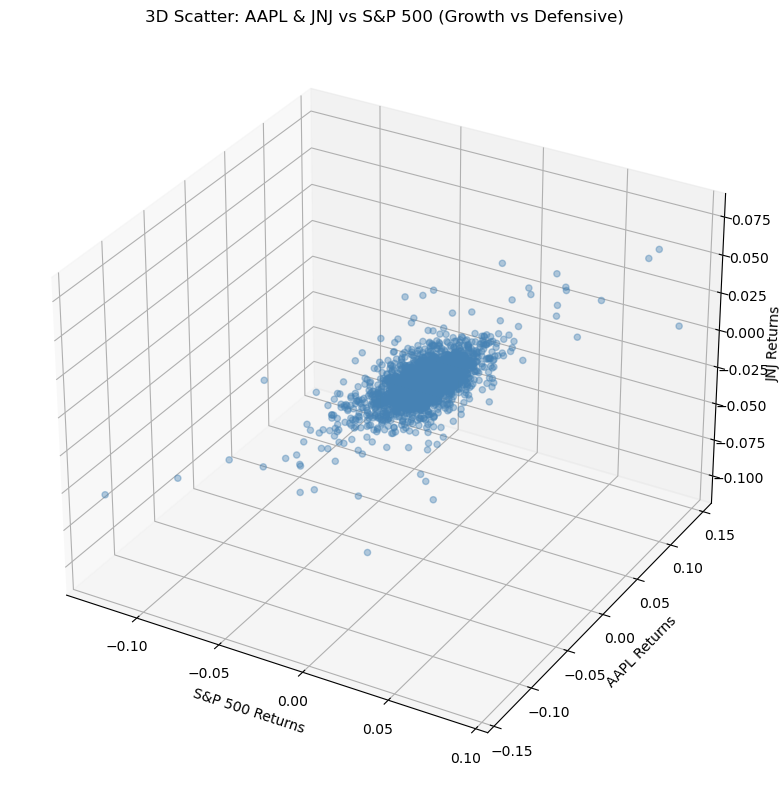

In [14]:
# ======================================================================
# SECTION 9 — Regression Analysis: Each Stock vs S&P 500
# ======================================================================
 
clean_data = log_return.dropna()
 
# --- 3D Scatter: AAPL & JNJ vs Market ---
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(
    clean_data["^GSPC"],
    clean_data["AAPL"],
    clean_data["JNJ"],
    c="steelblue", marker="o", alpha=0.4
)
ax.set_xlabel("S&P 500 Returns")
ax.set_ylabel("AAPL Returns")
ax.set_zlabel("JNJ Returns")
ax.set_title("3D Scatter: AAPL & JNJ vs S&P 500 (Growth vs Defensive)")
plt.tight_layout()
plt.show()

In [15]:
# --- OLS Regressions ---

X_market = sm.add_constant(clean_data["^GSPC"])
 
regression_results = {}
 
for stock in stocks:
    Y     = clean_data[stock]
    model = sm.OLS(Y, X_market).fit()
    regression_results[stock] = {
        "Beta"   : model.params["^GSPC"],
        "Alpha"  : model.params["const"],
        "R²"     : model.rsquared,
        "p-value": model.pvalues["^GSPC"]
    }
    print(f"\n{'='*50}")
    print(f"Model: {stock} vs S&P 500")
    print(f"{'='*50}")
    print(model.summary())


Model: SCHD vs S&P 500
                            OLS Regression Results                            
Dep. Variable:                   SCHD   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     9929.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        16:14:04   Log-Likelihood:                 11121.
No. Observations:                2853   AIC:                        -2.224e+04
Df Residuals:                    2851   BIC:                        -2.223e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.925e-05    9.2

                            OLS Regression Results                            
Dep. Variable:                     VZ   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     443.8
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.12e-91
Time:                        16:14:04   Log-Likelihood:                 8664.4
No. Observations:                2853   AIC:                        -1.732e+04
Df Residuals:                    2851   BIC:                        -1.731e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.003e-05      0.000      0.138      0.8

# Final Summary Dashboard

In [16]:
# ======================================================================
# SECTION 10 — Final Summary Dashboard
# ======================================================================
 
# --- Individual Asset Summary ---
print("\n\n" + "="*65)
print("       INDIVIDUAL ASSET RISK & RETURN SUMMARY")
print("="*65)
print(summary_individual.to_string())
 
# --- Beta & Regression Summary ---
beta_summary = pd.DataFrame(regression_results).T
beta_summary["Beta"]    = beta_summary["Beta"].round(3)
beta_summary["Alpha"]   = beta_summary["Alpha"].round(6)
beta_summary["R²"]      = beta_summary["R²"].round(3)
beta_summary["p-value"] = beta_summary["p-value"].apply(lambda x: f"{x:.2e}")
 
print("\n" + "="*65)
print("       BETA & REGRESSION SUMMARY (vs S&P 500)")
print("="*65)
print(beta_summary.to_string())



       INDIVIDUAL ASSET RISK & RETURN SUMMARY
        Annual Return (%)  Annual Variance  Volatility / Risk (%)  Sharpe Ratio
Ticker                                                                         
SCHD                10.86         0.026995                  16.43         0.400
VTI                 12.43         0.032338                  17.98         0.452
VOO                 12.92         0.031435                  17.73         0.486
VT                  10.46         0.029268                  17.11         0.360
VXUS                 7.93         0.029779                  17.26         0.210
QQQ                 17.67         0.047645                  21.83         0.613
AAPL                21.86         0.081773                  28.60         0.614
MSFT                20.55         0.072752                  26.97         0.603
NVDA                53.45         0.228904                  47.84         1.027
AMZN                25.17         0.106396                  32.62       

# Portfolio-Level Summary

In [17]:
# --- Portfolio-Level Summary ---

summary_portfolio = pd.DataFrame({
    "Annual Return (%)":        [round(portfolio_return     * 100, 2)],
    "Volatility (%)":           [round(portfolio_volatility * 100, 2)],
    "Sharpe Ratio":             [round((portfolio_return - rf) / portfolio_volatility, 3)],
    "Variance":                 [round(portfolio_variance,                             6)],
    "Undiversified Variance":   [round(wiv,                                            6)],
    "Diversification Benefit":  [round(diversification_benefit,                        6)],
    "Diversification Ratio (%)": [round((diversification_benefit / wiv) * 100,         1)]
}, index=[f"Portfolio (Equal Weight — {num_assets} Assets)"])
 
print("\n" + "="*65)
print("       FINAL PORTFOLIO SUMMARY")
print("="*65)
print(summary_portfolio.to_string())
 
print("\n Analysis complete — Quantitative Portfolio Optimization & Risk Assessment | Kesidis Angelos")


       FINAL PORTFOLIO SUMMARY
                                      Annual Return (%)  Volatility (%)  Sharpe Ratio  Variance  Undiversified Variance  Diversification Benefit  Diversification Ratio (%)
Portfolio (Equal Weight — 40 Assets)              14.21           17.21         0.576  0.029616                0.074606                  0.04499                       60.3

 Analysis complete — Quantitative Portfolio Optimization & Risk Assessment | Kesidis Angelos
